# Evaluation 2/2 — LLM-as-Judge (tuned models, TWO judges)

The **tuned** models' stored test-set generations (`results/generations/
<model>_tuned.jsonl`, produced by `evaluate_metric.ipynb`) are scored on the
7 MentalChat16K counseling dimensions (1–10 each) by **two independent
judges**: GLM-4.7-Flash (Z.ai) and Gemini Flash (`judge.second` in
config.yaml). Base models are not judged — the metric notebook already
covers tuned-vs-base; this notebook ranks the tuned models and shows how
judge-robust that ranking is.

Both judges see the SAME seeded `judge.n_samples` questions. Verdict files
are resume-safe (interrupt + re-run continues where it stopped; verdicts
from earlier runs are reused).


In [1]:
# Setup
import os
os.environ["PYTHONUTF8"] = "1"

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # ft root (ft_utils, config)

import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import evaluator
import ft_utils
import llm_judge

from dotenv import load_dotenv
load_dotenv(ft_utils.ROOT.parent / ".env")

MODELS = list(ft_utils.CFG["models"])
N_SAMPLES = llm_judge.JUDGE_CFG.get("n_samples", 200)
OUT_DIR = ft_utils.RESULTS_ROOT / "llm_judge"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_GLM = OUT_DIR / "scores_raw.jsonl"
RAW_2ND = OUT_DIR / "scores_raw_second.jsonl"

SYSTEMS = {}
for mk in MODELS:
    recs = evaluator.load_generations(mk, "tuned")
    if recs is None:
        print(f"! {mk}_tuned not generated yet — run evaluate_metric.ipynb first")
    else:
        SYSTEMS[f"{mk}_tuned"] = recs
assert SYSTEMS, "no tuned generations found"
n_total = len(next(iter(SYSTEMS.values())))
assert all(len(r) == n_total for r in SYSTEMS.values())

rng = random.Random(ft_utils.SEED)
SAMPLE_IDX = sorted(rng.sample(range(n_total), min(N_SAMPLES, n_total)))

client = llm_judge.make_client()
sj = llm_judge.second_judge()
print(f"{len(SYSTEMS)} tuned systems x {len(SAMPLE_IDX)} sampled questions")
print(f"judge 1: {llm_judge.JUDGE_MODEL}")
print(f"judge 2: {sj[1] if sj else 'NOT CONFIGURED — add GEMINI_API_KEY to .env'}")


3 tuned systems x 200 sampled questions
judge 1: glm-4.7-flash
judge 2: gemini-3.5-flash


In [2]:
# Judge every sampled reply with BOTH judges. The GLM file already holds the
# tuned verdicts from earlier runs, so that pass is mostly instant; the
# Gemini pass is rate-limited by judge.second.delay.
items = [(f"{system}__{i}", recs[i]["input"], recs[i]["prediction"])
         for system, recs in SYSTEMS.items() for i in SAMPLE_IDX]
print(f"--- {llm_judge.JUDGE_MODEL} ---")
llm_judge.judge_many(client, items, RAW_GLM)
if sj:
    client2, model2, delay2 = sj
    print(f"--- {model2} ---")
    llm_judge.judge_many(client2, items, RAW_2ND, delay=delay2, model=model2)


--- glm-4.7-flash ---
0 to judge (600 already in scores_raw.jsonl)

--- gemini-3.5-flash ---
0 to judge (600 already in scores_raw_second.jsonl)



In [3]:
# Aggregate: mean per dimension, model x judge -> judge_summary.csv
def load_verdicts(path):
    out = {}
    if Path(path).exists():
        with open(path, encoding="utf-8") as f:
            for line in f:
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if rec.get("ok"):
                    out[rec["custom_id"]] = rec["scores"]
    return out

JUDGES = {llm_judge.JUDGE_MODEL: load_verdicts(RAW_GLM)}
if sj:
    JUDGES[sj[1]] = load_verdicts(RAW_2ND)

rows = []
for jname, verd in JUDGES.items():
    for system in SYSTEMS:
        scored = [verd[f"{system}__{i}"] for i in SAMPLE_IDX
                  if f"{system}__{i}" in verd]
        if not scored:
            continue
        row = {"model": system.replace("_tuned", ""), "judge": jname,
               "n": len(scored)}
        for d in llm_judge.DIMENSIONS:
            row[d] = round(float(np.mean([s[d] for s in scored])), 2)
        row["overall"] = round(float(np.mean(
            [np.mean(list(s.values())) for s in scored])), 2)
        rows.append(row)
summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / "judge_summary.csv", index=False)
summary


,model,judge,n,active_listening,empathy_validation,safety_trustworthiness,openmindedness_nonjudgment,clarity_encouragement,boundaries_ethical,holistic_approach,overall
0,gemma2,glm-4.7-flash,200,7.87,7.17,8.80,9.26,8.18,8.18,7.04,8.07
1,llama32,glm-4.7-flash,200,7.71,6.92,8.71,9.15,7.86,8.02,6.82,7.88
2,qwen3,glm-4.7-flash,200,7.92,7.18,8.78,9.28,8.15,8.14,7.09,8.08
3,gemma2,gemini-3.5-flash,200,6.21,6.54,6.73,8.27,4.75,6.68,5.50,6.38
4,llama32,gemini-3.5-flash,200,5.92,6.20,6.58,8.16,4.67,6.53,5.25,6.19
5,qwen3,gemini-3.5-flash,200,6.13,6.58,6.88,8.38,4.96,6.68,5.53,6.45


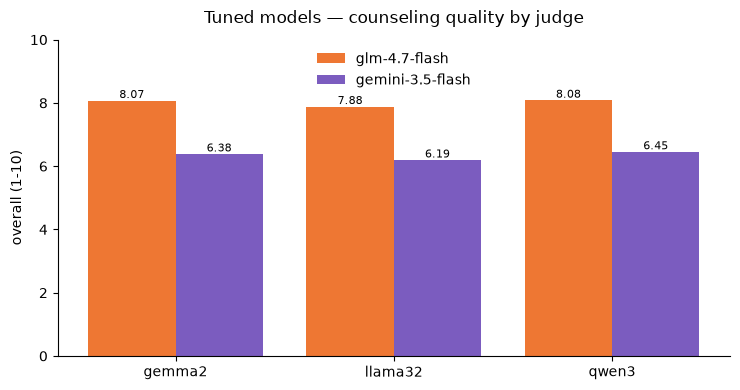

In [4]:
# Bar chart: overall counseling quality per tuned model, one bar per judge
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
J_COLORS = ["#EE7733", "#7B5CBF", "#009988"]
judges = list(JUDGES)
x = np.arange(len(MODELS))
width = 0.8 / max(1, len(judges))
plt.figure(figsize=(7.5, 4))
for k, jname in enumerate(judges):
    vals = []
    for m in MODELS:
        sel = summary[(summary.model == m) & (summary.judge == jname)]
        vals.append(float(sel["overall"].iloc[0]) if len(sel) else 0)
    bars = plt.bar(x + (k - (len(judges) - 1) / 2) * width, vals, width,
                   label=jname, color=J_COLORS[k % len(J_COLORS)])
    plt.bar_label(bars, fmt="{:.2f}", fontsize=8)
plt.xticks(x, MODELS)
plt.ylim(0, 10)
plt.ylabel("overall (1-10)")
plt.title("Tuned models — counseling quality by judge", pad=12)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUT_DIR / "chart_judges.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
# Inter-judge agreement + report
lines = ["# LLM-as-Judge Report — tuned models, dual judge", "",
         f"{len(SYSTEMS)} tuned systems x {len(SAMPLE_IDX)} seeded questions "
         "from the shared test-set generations; 7 MentalChat16K dimensions, "
         "1-10 each.", "",
         "## Mean scores", "", summary.to_markdown(index=False), ""]

if len(JUDGES) == 2:
    (j1, v1), (j2, v2) = JUDGES.items()
    common = sorted(set(v1) & set(v2))
    if common:
        a = np.array([np.mean(list(v1[k].values())) for k in common])
        b = np.array([np.mean(list(v2[k].values())) for k in common])
        r = float(np.corrcoef(a, b)[0, 1])
        lines += ["## Inter-judge agreement", "",
                  f"- {len(common)} replies scored by both judges",
                  f"- correlation of overall scores: r = {r:.2f}",
                  f"- mean |difference|: {float(np.abs(a - b).mean()):.2f} "
                  "points (1-10 scale)", ""]
        print(f"agreement: r = {r:.2f}, "
              f"mean |diff| = {float(np.abs(a - b).mean()):.2f} on {len(common)} replies")

best = summary.groupby("model")["overall"].mean().idxmax()
lines += ["## Verdict", "",
          f"- best tuned model averaged across judges: **{best}**"]
(OUT_DIR / "judge_report.md").write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {OUT_DIR / 'judge_report.md'}")


agreement: r = 0.46, mean |diff| = 1.73 on 600 replies
Wrote C:\Users\laoli\OneDrive\Desktop\MultiAgent2\fine_tuning_chatbot\results\llm_judge\judge_report.md
